In [1]:
import pandas as pd
import warnings
warnings.filterwarnings('ignore')

In [2]:
matches = pd.read_csv("matches.csv")
deliveries = pd.read_csv("deliveries.csv")

In [3]:
matches.head()

,id,season,city,date,match_type,player_of_match,venue,team1,team2,toss_winner,toss_decision,winner,result,result_margin,target_runs,target_overs,super_over,method,umpire1,umpire2
0,335982,2007/08,Bangalore,2008-04-18,League,BB McCullum,M Chinnaswamy Stadium,Royal Challengers Bangalore,Kolkata Knight Riders,Royal Challengers Bangalore,field,Kolkata Knight Riders,runs,140.0,223.0,20.0,N,NaN,Asad Rauf,RE Koertzen
1,335983,2007/08,Chandigarh,2008-04-19,League,MEK Hussey,"Punjab Cricket Association Stadium, Mohali",Kings XI Punjab,Chennai Super Kings,Chennai Super Kings,bat,Chennai Super Kings,runs,33.0,241.0,20.0,N,NaN,MR Benson,SL Shastri
2,335984,2007/08,Delhi,2008-04-19,League,MF Maharoof,Feroz Shah Kotla,Delhi Daredevils,Rajasthan Royals,Rajasthan Royals,bat,Delhi Daredevils,wickets,9.0,130.0,20.0,N,NaN,Aleem Dar,GA Pratapkumar
3,335985,2007/08,Mumbai,2008-04-20,League,MV Boucher,Wankhede Stadium,Mumbai Indians,Royal Challengers Bangalore,Mumbai Indians,bat,Royal Challengers Bangalore,wickets,5.0,166.0,20.0,N,NaN,SJ Davis,DJ Harper
4,335986,2007/08,Kolkata,2008-04-20,League,DJ Hussey,Eden Gardens,Kolkata Knight Riders,Deccan Chargers,Deccan Chargers,bat,Kolkata Knight Riders,wickets,5.0,111.0,20.0,N,NaN,BF Bowden,K Hariharan


In [4]:
deliveries.head()

,match_id,inning,batting_team,bowling_team,over,ball,batter,bowler,non_striker,batsman_runs,extra_runs,total_runs,extras_type,is_wicket,player_dismissed,dismissal_kind,fielder
0,335982,1,Kolkata Knight Riders,Royal Challengers Bangalore,0,1,SC Ganguly,P Kumar,BB McCullum,0,1,1,legbyes,0,NaN,NaN,NaN
1,335982,1,Kolkata Knight Riders,Royal Challengers Bangalore,0,2,BB McCullum,P Kumar,SC Ganguly,0,0,0,NaN,0,NaN,NaN,NaN
2,335982,1,Kolkata Knight Riders,Royal Challengers Bangalore,0,3,BB McCullum,P Kumar,SC Ganguly,0,1,1,wides,0,NaN,NaN,NaN
3,335982,1,Kolkata Knight Riders,Royal Challengers Bangalore,0,4,BB McCullum,P Kumar,SC Ganguly,0,0,0,NaN,0,NaN,NaN,NaN
4,335982,1,Kolkata Knight Riders,Royal Challengers Bangalore,0,5,BB McCullum,P Kumar,SC Ganguly,0,0,0,NaN,0,NaN,NaN,NaN


In [5]:
matches = matches.rename(columns={'id': 'match_id'})

In [6]:
df = deliveries.merge(matches, on='match_id')

In [7]:
df = df[df['inning'] == 2]

In [8]:
total_score_df = deliveries.groupby(['match_id','inning']).sum()['total_runs'].reset_index()

# get 1st innings score
first_innings = total_score_df[total_score_df['inning'] == 1]

# rename
first_innings = first_innings.rename(columns={'total_runs':'target'})

# merge with main df
df = df.merge(first_innings[['match_id','target']], on='match_id')

# target = +1 run
df['target'] = df['target'] + 1

In [9]:
df['current_score'] = df.groupby('match_id')['total_runs'].cumsum()

In [10]:
df['ball_number'] = df['over']*6 + df['ball']

df['balls_remaining'] = 120 - df['ball_number']

In [11]:
df['player_dismissed'] = df['player_dismissed'].fillna(0)

df['is_wicket'] = df['player_dismissed'].apply(lambda x: 0 if x == 0 else 1)

df['wickets_fallen'] = df.groupby('match_id')['is_wicket'].cumsum()

df['wickets_remaining'] = 10 - df['wickets_fallen']

In [12]:
df['current_run_rate'] = df['current_score'] / (df['ball_number']/6)

df['runs_remaining'] = df['target'] - df['current_score']

df['required_run_rate'] = df['runs_remaining'] / (df['balls_remaining']/6)

In [13]:
# winner column already in matches
df['batting_team'] = df['batting_team']

df['result'] = df.apply(
    lambda row: 1 if row['batting_team'] == row['winner'] else 0,
    axis=1
)

In [14]:
df = df[df['balls_remaining'] > 0]

In [15]:
final_df = df[[
    'balls_remaining',
    'wickets_remaining',
    'current_run_rate',
    'required_run_rate',
    'result'
]]

final_df = final_df.dropna()

In [16]:
import numpy as np

final_df = final_df.replace([np.inf, -np.inf], np.nan)
final_df = final_df.dropna()

In [17]:
print(final_df.isnull().sum())
print(np.isinf(final_df).sum())

balls_remaining      0
wickets_remaining    0
current_run_rate     0
required_run_rate    0
result               0
dtype: int64
balls_remaining      0
wickets_remaining    0
current_run_rate     0
required_run_rate    0
result               0
dtype: int64


In [18]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression

X = final_df.drop('result', axis=1)
y = final_df['result']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

model = LogisticRegression()
model.fit(X_train, y_train)

print("Accuracy:", model.score(X_test, y_test))

Accuracy: 0.7802676253245456


In [19]:
model.fit(X_train, y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,100
,multi_class,'deprecated'


In [20]:
from sklearn.metrics import confusion_matrix

y_pred = model.predict(X_test)

print(confusion_matrix(y_test, y_pred))

[[ 8967  3094]
 [ 2407 10567]]


In [21]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.79      0.74      0.77     12061
           1       0.77      0.81      0.79     12974

    accuracy                           0.78     25035
   macro avg       0.78      0.78      0.78     25035
weighted avg       0.78      0.78      0.78     25035



In [22]:
from sklearn.metrics import roc_auc_score

y_prob = model.predict_proba(X_test)[:,1]

print("ROC-AUC:", roc_auc_score(y_test, y_prob))

ROC-AUC: 0.8677559496739936


In [23]:
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, roc_auc_score

xgb = XGBClassifier(
    n_estimators=200,
    max_depth=4,
    learning_rate=0.05,
    reg_lambda=1,
    reg_alpha=0.5,
    random_state=42
)
xgb.fit(X_train, y_train)

# predictions
y_pred = xgb.predict(X_test)
y_prob = xgb.predict_proba(X_test)[:,1]

print("Accuracy:", accuracy_score(y_test, y_pred))
print("ROC-AUC:", roc_auc_score(y_test, y_prob))

Accuracy: 0.7844218094667466
ROC-AUC: 0.877760738546733


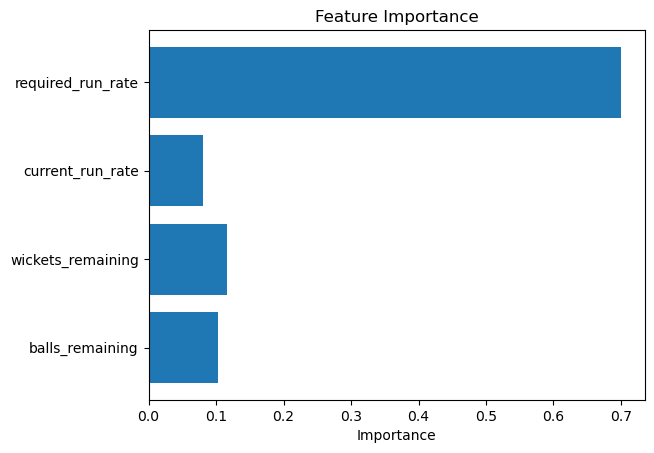

In [24]:
import matplotlib.pyplot as plt

importances = xgb.feature_importances_
features = X.columns

plt.barh(features, importances)
plt.xlabel("Importance")
plt.title("Feature Importance")
plt.show()

In [25]:
import os
import pickle

os.makedirs("models", exist_ok=True)

pickle.dump(xgb, open("models/xgb_model.pkl", "wb"))

In [26]:
model = pickle.load(open("models/xgb_model.pkl", "rb"))

model.predict_proba([[30,5,8.5,9.2]])

array([[0.44212496, 0.55787504]], dtype=float32)